# RFM Analysis — Online Retail Store

## Business Problem
An online retail store has transaction data of its customers but lacks visibility into customer behavior and value. There is no segmentation or identification of customer types. Some customers visit frequently but spend very little. High-value customers who generate significant revenue are at risk of churning and not returning. Some customers take long gaps before making another purchase. The business needs a structured approach to understand and classify its customer base.

## Objective
The objective of this analysis is to segment customers using RFM Analysis:
- **Recency (R):** Gap between the customer's last purchase and today
- **Frequency (F):** Number of times a customer made a purchase
- **Monetary (M):** Total amount of money a customer spent

By identifying these segments, the business can prioritize retention, re-engagement, and reward strategies accordingly.

## Dataset
- **Source:** UCI Machine Learning Repository — Online Retail Dataset
- **Rows:** ~541,909
- **Columns:** 8
- **Key Columns:** CustomerID, InvoiceNo, InvoiceDate, Quantity, UnitPrice, StockCode, Description, Country

## Project Phases
- **Phase 0:** Data overview in Excel
- **Phase 1:** Data cleaning + EDA in Python
- **Phase 2:** RFM calculation + customer segmentation in Python
- **Phase 3:** Dashboard in Power BI
- **Phase 4:** Business queries in MySQL
- **Phase 5:** Business insights + recommendations

---








## 1.4 Missing Value Treatment
- Identify missing values
- Drop null CustomerID rows
- Ignore null Description rows

## 1.5 Removing Duplicates

## 1.6 Handling Cancelled Orders
- Drop rows where InvoiceNo starts with 'C'

## 1.7 Handling Negative and Zero UnitPrice

## 1.8 Data Type Fixing
- Convert InvoiceDate to datetime format

## 1.9 Adding New Column
- Create TotalPrice = Quantity × UnitPrice

## 1.10 Exploratory Data Analysis (EDA)
- Distribution of sales by country
- Monthly revenue trend
- Top customers by revenue
- Order frequency distribution

# Phase 1 — Data Cleaning + EDA in Python

## 1.1 Import Libraries

In [1]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1.2 Load Dataset


In [18]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\project2\Dataset\data.csv', encoding = 'latin1')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



## 1.3 Initial Data Overview
- Shape of dataset
- Column names and data types
- First few rows

In [24]:
df.shape

(541909, 8)

-- Rows - 541909, Columns - 8

- Column names and data types


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


**Key Observations from df.info():**
- 135,080 missing values in CustomerID — critical, must drop
- 1,454 missing values in Description — not critical for RFM, will ignore
- InvoiceDate is string — needs conversion to datetime
- CustomerID is float64 — will convert to int after dropping nulls

In [28]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 1.4 Missing Value Treatment
- Identify missing values
- Drop null CustomerID rows
- Ignore null Description rows

In [29]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

* Observation: 135,080 nulls in CustomerID, 1,454 in Description*

- Drop null CustomerID rows

In [31]:
df.dropna(subset=['CustomerID'], inplace=True)

In [32]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

*- All null value dropped*

## 1.5 Removing Duplicates

- Checking Dublicate values

In [34]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 5225


*- 5225 dublicate value found*

- Dropping dublicate value

In [35]:
df.drop_duplicates(inplace=True)
print('Rows after dropping duplicates:', df.shape[0])

Rows after dropping duplicates: 401604


## 1.6 Handling Cancelled Orders
- Drop rows where InvoiceNo starts with 'C'

In [36]:
cancelled = df['InvoiceNo'].str.startswith('C')
df = df[~cancelled]
print('Rows after removing cancelled orders:', df.shape[0])

Rows after removing cancelled orders: 392732


## 1.7 Handling Negative and Zero UnitPrice

In [38]:
df = df[df['UnitPrice'] > 0]
print('Rows after removing negative and zero UnitPrice:', df.shape[0])

Rows after removing negative and zero UnitPrice: 392692


*- Removed negative and zero UnitPrice rows. 392,692 clean rows remaining.*

## 1.8 Data Type Fixing
- Convert InvoiceDate to datetime format


In [41]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].dtype)

datetime64[us]


*-InvoiceDate successfully converted from string to datetime64 format*

## 1.9 Adding New Column
- Create TotalPrice = Quantity × UnitPrice

In [46]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df[['TotalPrice', 'Quantity', 'UnitPrice']].head()

,TotalPrice,Quantity,UnitPrice
0,15.30,6,2.55
1,20.34,6,3.39
2,22.00,8,2.75
3,20.34,6,3.39
4,20.34,6,3.39


*-TotalPrice column created*

In [50]:
df.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.0 MB


In [51]:
df['CustomerID'] = df['CustomerID'].astype(int)

df.info()


## 1.10 Exploratory Data Analysis (EDA)
- Distribution of sales by country
- Monthly revenue trend
- Top customers by revenue
- Order frequency distribution

#### Distribution of sales by country


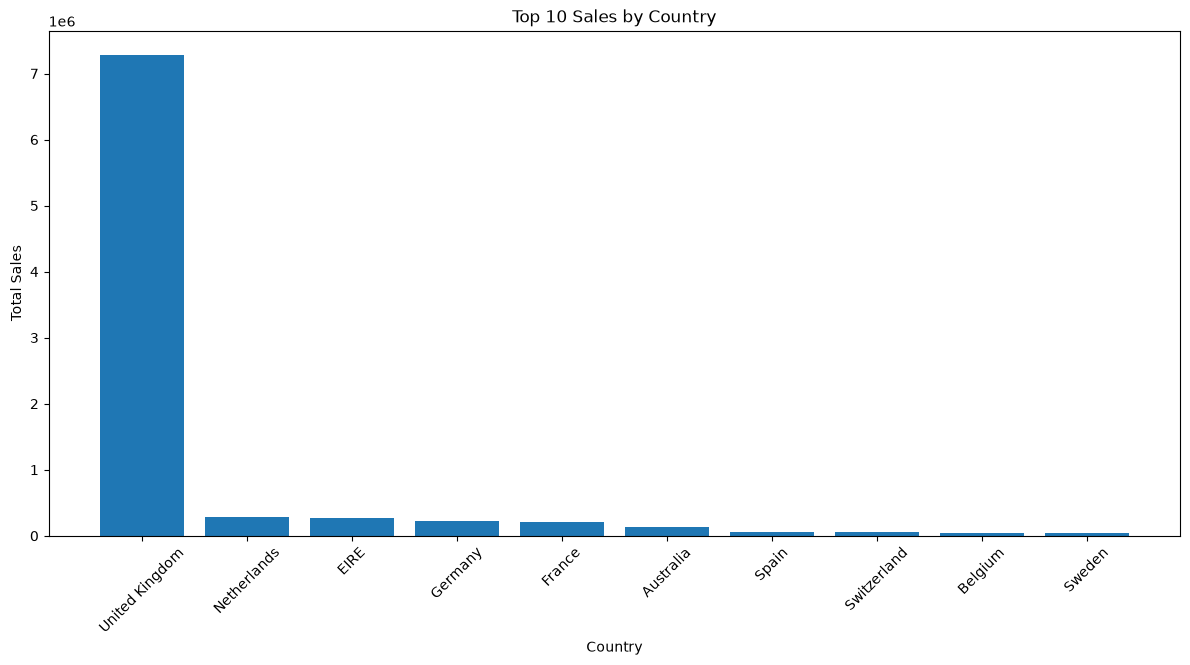

In [63]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending= False).head(10)
plt.figure(figsize= (12,6))
plt.bar(country_sales.index, country_sales.values)
plt.title('Top 10 Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

*- Observation:*
*- United Kingdom dominates with ~7.2M in sales.*
*- This is expected as the store is UK-based.*
*- Netherlands, EIRE and Germany are the next top markets but significantly smaller.*

#### Monthly revenue trend

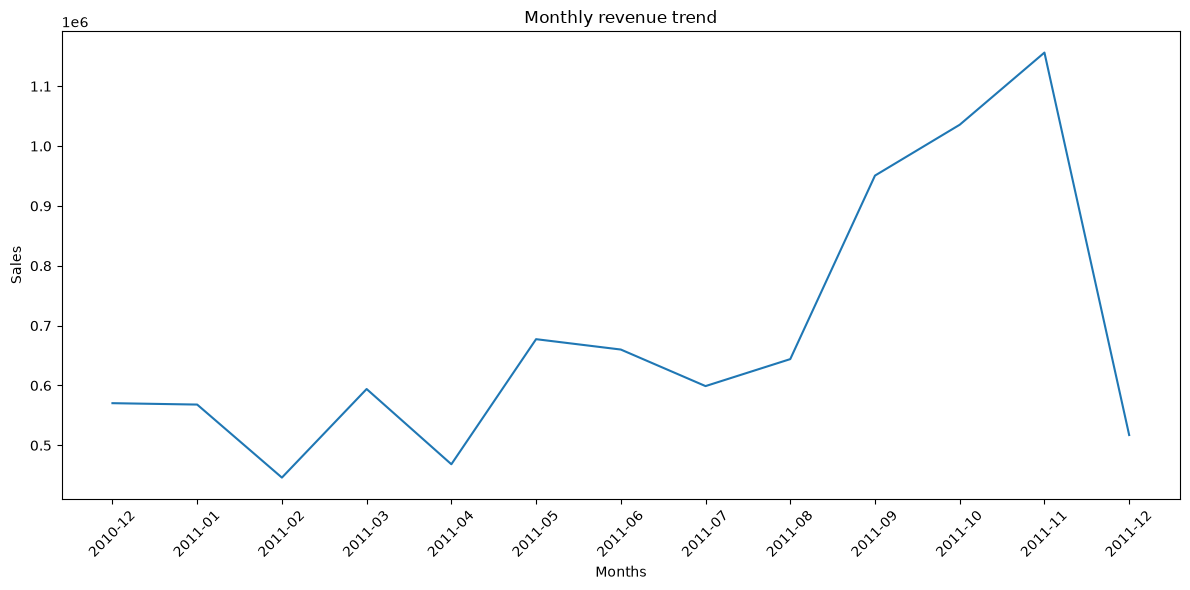

In [67]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum()

plt.figure(figsize= (12,6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)
plt.title('Monthly revenue trend')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

*- Observation: Revenue peaks in November 2011 (~1.14M) - likely Christmas season demand.*

*- Sharp December 2011 drop is due to incomplete data, not actual decline.*

*- Overall upward revenue trend visible in second half of 2011.*

#### Top 10 customer by revenue

*List of top 10 Customer By revenue*

In [71]:
top_customer = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending= False).head(10)
print(top_customer)

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: TotalPrice, dtype: float64


*Visualiation of Top 10 Customer by Revenue*

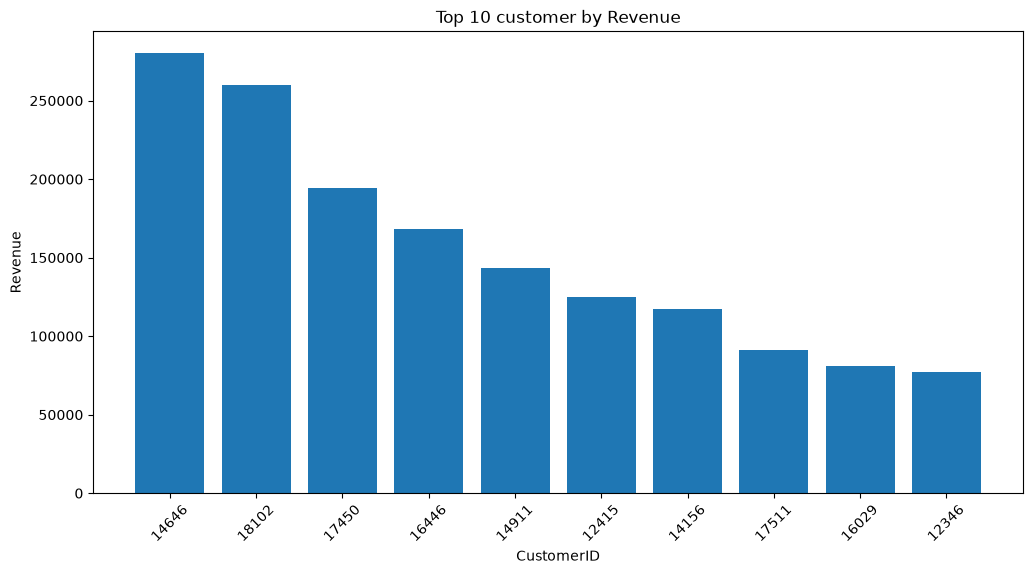

In [79]:
plt.figure(figsize= (12,6))
plt.bar(top_customer.index.astype(str), top_customer.values)
plt.title('Top 10 customer by Revenue')
plt.xlabel('CustomerID')
plt.ylabel('Revenue')
plt.xticks(rotation = 45)
plt.show()

*- Observation: Customer 14646 is the highest revenue generator (~275K).*


*- Top 2 customers (14646, 18102) are significantly ahead of the rest.*


*- These are high-value customers - retention of these is critical for the business.*

#### Order Frequency Distribution

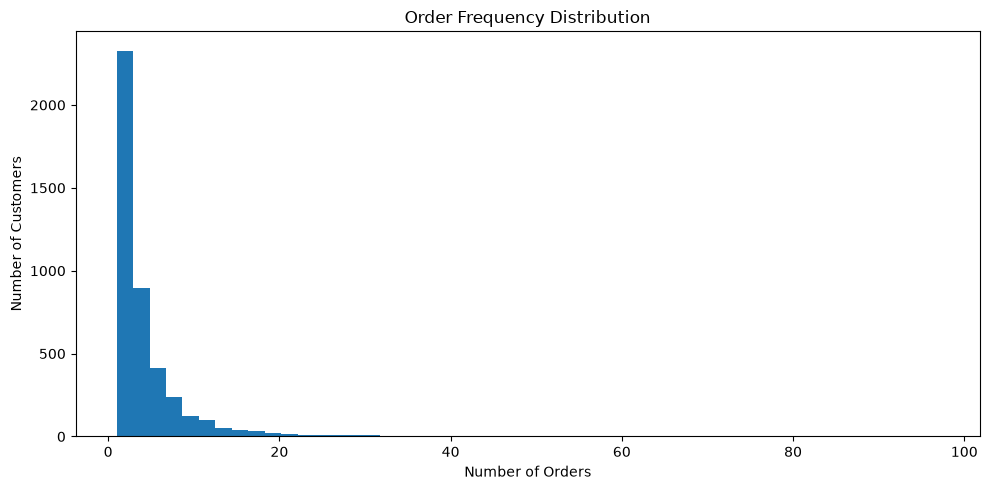

In [84]:
order_freq = df.groupby('CustomerID')['InvoiceNo'].nunique()
order_freq = order_freq[order_freq < 100]

plt.figure(figsize=(10, 5))
plt.hist(order_freq, bins=50)
plt.title('Order Frequency Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

*- Observation:*

*-Majority of customers placed only 1-5 orders.*

*- Very few customers placed more than 20 orders.*

*-This is a classic right-skewed distribution - typical in retail customer behavior.*


*- High frequency customers (20+ orders) are rare but likely high value segments.*

In [86]:
print(df['CustomerID'].dtype)

int64


In [89]:
df.to_csv(r'C:\Users\HP\OneDrive\Desktop\project2\Dataset\rfm_cleaned.csv', index=False)
print('File saved successfully')

File saved successfully
